# Time Series Validation Strategies

In Section 7 (Lesson 14), we learned that the ultimate way to evaluate a machine learning model is **K-Fold Cross-Validation**. We chopped our dataset into 5 random blocks, trained on 4, and tested on 1. It mathematically eliminated the variance of a lucky split.

If you use standard K-Fold Cross-Validation on a Time Series model in an enterprise environment, **you will likely be fired.**

In this lesson, we will explore the catastrophic trap of Temporal Data Leakage (Look-Ahead Bias) and introduce the specialized validation architectures required to safely test forecasting algorithms.

The golden rule of Time Series validation is strict chronological isolation: **An algorithm must never be allowed to look into the future to predict the past.** Let's set up our Python environment to slice time safely.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, TimeSeriesSplit

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Temporal Validation Environment Ready.")

✅ Temporal Validation Environment Ready.


# 1. The Catastrophe of Standard K-Fold (Data Leakage)

Imagine we have 5 months of stock market data: January, February, March, April, and May.
We want to test if our model can predict the stock price.

If we use standard `KFold(n_splits=5)`, the algorithm will randomly shuffle the blocks.

* **Iteration 1**: Trains on Jan, Feb, Apr, May. Tests on **March**.

Do you see the mathematical paradox? To predict what happened in March, the algorithm was allowed to read the data from April and May. It used future information to backcast the past. The model will score a $99\%$ accuracy in validation, and when you deploy it into production (where it cannot see tomorrow's data), it will crash instantly. This is called **Look-Ahead Bias**.

# 2. Strategy 1: Expanding Window (Time Series Split)

To maintain chronological integrity, we use an **Expanding Window** (implemented in Scikit-Learn as `TimeSeriesSplit`).

In this architecture, the training set always starts at the beginning of the timeline and grows larger with every iteration, while the test set strictly follows immediately after it.

* **Iteration 1**: Train on Jan $\rightarrow$ Test on Feb
* **Iteration 2**: Train on Jan, Feb $\rightarrow$ Test on Mar
* **Iteration 3**: Train on Jan, Feb, Mar $\rightarrow$ Test on Apr

### The Mathematical Properties

Let the total time series be $T$.
Let the test horizon be $h$ (the number of steps we want to forecast).
For each fold $k$, the training set contains observations $y_1, \dots, y_t$, and the test set contains $y_{t+1}, \dots, y_{t+h}$. As $k$ increases, $t$ increases.



# 3. Strategy 2: Rolling Window (Walk-Forward Validation)

The Expanding Window strategy has a fatal flaw: **Concept Drift**.
If you are forecasting airline ticket sales in 2024, do you really want your algorithm training on data from 2018? The world has fundamentally changed. Ancient data might actually *corrupt* the model's understanding of the present.

To solve this, enterprise Data Scientists use a **Rolling Window** (Walk-Forward Validation). The training set does not grow; it remains a fixed mathematical size and physically slides forward through time.

* **Iteration 1**: Train on Jan, Feb, Mar $\rightarrow$ Test on Apr
* **Iteration 2**: Train on Feb, Mar, Apr $\rightarrow$ Test on May
* **Iteration 3**: Train on Mar, Apr, May $\rightarrow$ Test on Jun

By doing this, the model constantly "forgets" the ancient past, forcing it to adapt to recent structural changes in the business.

# 4. Visualizing Validation Splits in Code

Let's generate a simulated dataset of 100 days and visually compare how a standard K-Fold algorithm slices the data versus how a `TimeSeriesSplit` slices the data.


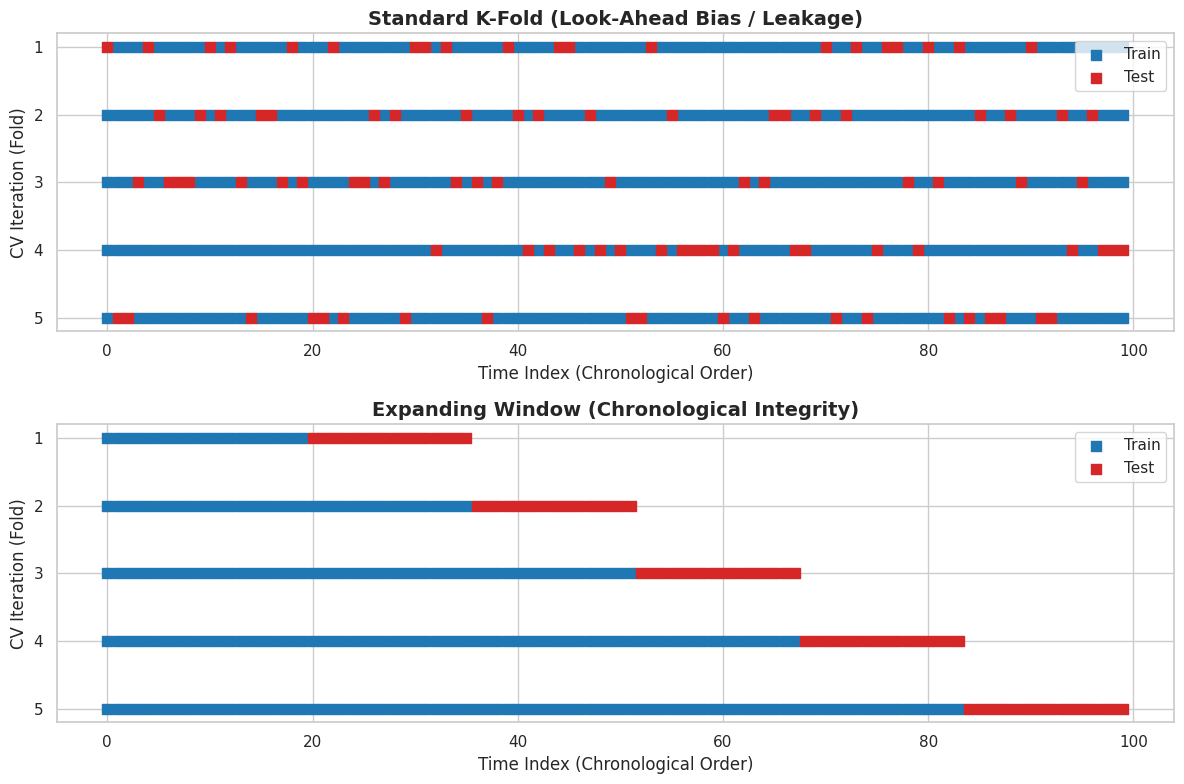

In [2]:
# 1. Simulate 100 days of data
X = np.arange(100)
y = np.random.randn(100)

# 2. Define the Splitters
# BAD: Standard K-Fold (Randomized)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# GOOD: Expanding Window Time Series Split
tscv = TimeSeriesSplit(n_splits=5)

# 3. Matplotlib Visualization function
def plot_cv_indices(cv, X, ax, title):
    """Visualizes the Train/Test indices for a given CV strategy."""
    for ii, (tr, tt) in enumerate(cv.split(X)):
        # Plot training data in Blue
        ax.scatter(tr, [ii + 1] * len(tr), c='#1f77b4', marker='s', s=50, label='Train' if ii == 0 else "")
        # Plot testing data in Red
        ax.scatter(tt, [ii + 1] * len(tt), c='#d62728', marker='s', s=50, label='Test' if ii == 0 else "")
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Time Index (Chronological Order)")
    ax.set_ylabel("CV Iteration (Fold)")
    ax.set_yticks(np.arange(1, cv.n_splits + 1))
    ax.invert_yaxis()
    ax.legend(loc='upper right')

# 4. Render the Plots
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: The Catastrophe of K-Fold
plot_cv_indices(kfold, X, axes[0], "Standard K-Fold (Look-Ahead Bias / Leakage)")

# Plot 2: The Safety of Time Series Split
plot_cv_indices(tscv, X, axes[1], "Expanding Window (Chronological Integrity)")

plt.tight_layout()
plt.show()

*(Insight: Look at the top plot. In Iteration 1, the red test points are randomly scattered *behind* and *between* the blue training points. The model is seeing the future! Now look at the bottom plot. The blue training block always precedes the red test block. The chronological timeline is mathematically respected!)*

# 5. Matching the Horizon ($h$)

When designing your Time Series Split, the size of your red Test Set should explicitly match your business forecasting horizon ($h$).

If your business needs a 30-day forecast, you must set your test block size to exactly 30 days. Evaluating a model's accuracy on a 1-day forecast will give you false confidence if you intend to deploy it to make 30-day predictions (because errors compound recursively over time).

## Real-World Use Case or Analogy:

Think of Time Series Validation like **Testing a Sports Bettor's Skills**:

* **Standard K-Fold (The Time Traveler)**: You want to test if someone is good at predicting NFL games. You give them the final scores from Week 1, Week 3, Week 4, and Week 5, and then ask them to predict the score of Week 2. They accurately predict Week 2 because they know exactly which players got injured in Week 3! This is cheating.
* **Expanding Window (The Historian)**: You ask them to predict Week 4. They are only allowed to look at tapes from Weeks 1, 2, and 3. As the season progresses, their library of tapes gets larger.
* **Rolling Window (Walk-Forward)**: You ask them to predict Week 12. You only let them watch tapes from Weeks 9, 10, and 11. You force them to ignore Week 1 because a star quarterback was traded in Week 8, meaning the data from Week 1 is now fundamentally useless and misleading.

---